# Data Cleanser

## Patient Health Records – Data Preprocessing & Feature Engineering

### Project Objective

The objective of this project is to clean and prepare a synthetic
patient health dataset for downstream machine learning.

The project focuses on:

- Missing value analysis
- Missing value imputation
- Multivariate imputation
- Outlier detection
- Outlier treatment
- Dataset validation
- Preparation of a machine-learning-ready dataset

## Project Requirements Checklist

Before starting the analysis, I identified the main tasks that need to be completed.

| Requirement | Planned Section |
|---|---|
| Inspect the raw dataset | Sections 1–9 |
| Identify missing values | Section 10 |
| Mean/median numerical imputation | Section 11 |
| Most-frequent categorical imputation | Section 11 |
| Missing indicators + random sample imputation | Section 12 |
| KNN imputation | Section 13 |
| MICE-style iterative imputation | Section 13 |
| Z-score outlier detection | Section 14 |
| IQR outlier detection | Section 14 |
| Percentile outlier detection | Section 14 |
| Outlier removal comparison | Section 15 |
| Winsorization | Section 16 |
| Select final cleaning strategy | Section 17 |
| Validate the cleaned dataset | Sections 17–18 |
| Save final dataset | Section 19 |

I will work through these requirements one at a time and keep the raw dataset unchanged throughout the experiments.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

from scipy import stats

## 1. Loading the Dataset

Before cleaning the data, I first need to load the raw patient records and make sure that the file has been read correctly.

At this stage, I am not changing or cleaning anything. The purpose is to understand what the original dataset looks like before any preprocessing is performed.

Keeping the original dataset unchanged at the beginning is important because it gives us a baseline that we can compare against after cleaning.

In [2]:
# Load the raw patient health records
df = pd.read_csv("patient_health_records_raw.csv")

# Display the first few records
df.head()

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,6253,72.0,Male,West,25.48,110.02,171.57,127.54,0
1,4685,75.0,NaN,West,31.23,129.08,218.11,78.10,0
2,1732,30.0,Male,North,28.51,111.57,247.28,92.61,0
3,4743,27.0,Female,South,27.01,98.12,198.51,74.52,1
4,4522,36.0,Female,North,30.86,119.34,196.18,NaN,1


## 2. Understanding the Dataset Structure

Now that the dataset has been loaded, I will perform a basic inspection.

I want to answer a few simple questions before beginning the cleaning process:

- How many records are there?
- How many variables are available?
- What are the column names?
- What data types are being used?
- Are there any obvious issues that need attention?

This gives me a starting point for the rest of the analysis.

In [3]:
# Check the number of rows and columns
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 10000
Number of columns: 9


In [4]:
# Display all column names
print("Columns in the dataset:")
print(df.columns.tolist())

Columns in the dataset:
['patient_id', 'age', 'gender', 'region', 'bmi', 'blood_pressure', 'cholesterol', 'glucose', 'disease_risk']


In [5]:
# Check the data type of each column
df.dtypes

patient_id          int64
age               float64
gender             object
region             object
bmi               float64
blood_pressure    float64
cholesterol       float64
glucose           float64
disease_risk        int64
dtype: object

## 3. Inspecting Data Types and Missing Values

The next step is to use `info()` to get a quick overview of the dataset.

This is useful because it shows the number of non-null values in each column and helps us identify columns that contain missing data.

I am using this before performing any imputation so that the cleaning decisions are based on the actual condition of the raw dataset.

In [6]:
# Display a compact summary of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   patient_id      10000 non-null  int64  
 1   age             9700 non-null   float64
 2   gender          9750 non-null   object 
 3   region          9700 non-null   object 
 4   bmi             9650 non-null   float64
 5   blood_pressure  10000 non-null  float64
 6   cholesterol     9700 non-null   float64
 7   glucose         9650 non-null   float64
 8   disease_risk    10000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 703.3+ KB


## 4. Statistical Summary

I will now look at the descriptive statistics for the numerical variables.

This gives me an initial idea of the typical values, spread, minimum values and maximum values in the dataset.

It is especially useful for this project because some of the columns contain synthetic outliers. Comparing these statistics before and after outlier treatment will help me evaluate whether the cleaning process improved the dataset.

In [7]:
# Display descriptive statistics for numerical columns
df.describe()

,patient_id,age,bmi,blood_pressure,cholesterol,glucose,disease_risk
count,10000.00000,9700.000000,9650.000000,10000.000000,9700.000000,9650.000000,10000.000000
mean,5000.50000,51.533093,26.117213,126.572671,196.425623,108.459967,0.621900
std,2886.89568,19.587409,5.169672,20.536699,44.554754,42.713376,0.484937
min,1.00000,18.000000,8.000000,85.000000,50.000000,55.000000,0.000000
25%,2500.75000,35.000000,22.962500,115.217500,171.310000,88.362500,0.000000
50%,5000.50000,51.000000,25.965000,125.215000,195.010000,104.720000,1.000000
75%,7500.25000,69.000000,28.977500,135.622500,219.080000,122.125000,1.000000
max,10000.00000,85.000000,65.000000,300.000000,600.000000,600.000000,1.000000


## 5. Checking for Duplicate Records

Before changing the dataset, I will check whether any complete duplicate rows are present.

Duplicate records can cause some observations to be counted more than once and may affect later analysis.

If duplicates are found, they should be investigated before deciding whether they should be removed.

In [8]:
# Count completely duplicated rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


## 6. Checking Patient IDs

The `patient_id` column is an identifier rather than a medical measurement.

Each patient should have a unique ID, so I will check whether the number of unique IDs matches the number of records.

I will also make sure that the identifier itself is not accidentally treated as a feature that needs imputation or outlier treatment.

In [9]:
# Check whether every patient has a unique ID
unique_ids = df["patient_id"].nunique()
total_records = len(df)

print("Total records:", total_records)
print("Unique patient IDs:", unique_ids)

if unique_ids == total_records:
    print("✓ Every patient ID is unique.")
else:
    print("⚠ Duplicate patient IDs were found.")

Total records: 10000
Unique patient IDs: 10000
✓ Every patient ID is unique.


## 7. Exploring Categorical Variables

The dataset contains two categorical variables:

- `gender`
- `region`

Before imputing missing categories, I want to understand the values that are already present.

This will also help when comparing the original category distribution with the distribution after imputation.

In [10]:
# Check the distribution of the categorical variables
print("Gender distribution:")
print(df["gender"].value_counts(dropna=False))

print("\nRegion distribution:")
print(df["region"].value_counts(dropna=False))

Gender distribution:
gender
Male      4907
Female    4843
NaN        250
Name: count, dtype: int64

Region distribution:
region
West     2471
South    2441
East     2422
North    2366
NaN       300
Name: count, dtype: int64


## 8. Exploring the Target Variable

The target variable for the downstream machine learning task is `disease_risk`.

It is a binary variable:

- `0` represents low risk.
- `1` represents high risk.

The target is kept separate from the missing-value and outlier treatment applied to the predictor variables.

I will first check its distribution so that I have a baseline for comparison later.

In [11]:
# Count each disease-risk category
risk_counts = df["disease_risk"].value_counts().sort_index()

print("Disease Risk Counts:")
print(risk_counts)

print("\nDisease Risk Percentages:")
print(
    (df["disease_risk"].value_counts(normalize=True).sort_index() * 100)
    .round(2)
)

Disease Risk Counts:
disease_risk
0    3781
1    6219
Name: count, dtype: int64

Disease Risk Percentages:
disease_risk
0    37.81
1    62.19
Name: proportion, dtype: float64


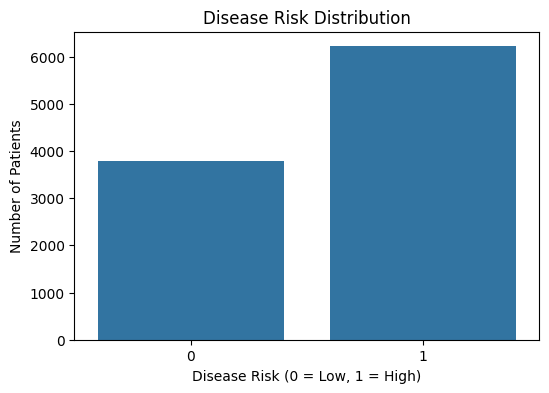

In [12]:
# Visualize the target distribution
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="disease_risk")

plt.title("Disease Risk Distribution")
plt.xlabel("Disease Risk (0 = Low, 1 = High)")
plt.ylabel("Number of Patients")

plt.show()

## 9. Initial Data Quality Summary

At this point, I have completed the initial inspection of the raw dataset.

The dataset contains 10,000 patient records and 9 variables. The patient IDs are unique and there are no completely duplicated rows.

The next step is to investigate missing values in more detail. This is important because the assignment requires several different imputation strategies, so I need to understand exactly where the missing data occurs before applying any method.

In [13]:
# Create a quick baseline summary
summary = pd.DataFrame({
    "Rows": [df.shape[0]],
    "Columns": [df.shape[1]],
    "Duplicate Rows": [df.duplicated().sum()],
    "Unique Patient IDs": [df["patient_id"].nunique()],
    "Total Missing Values": [df.isna().sum().sum()]
})

summary

,Rows,Columns,Duplicate Rows,Unique Patient IDs,Total Missing Values
0,10000,9,0,10000,1850


# 10. Missing Value Analysis

Missing values are one of the main problems in this dataset.

Before choosing an imputation strategy, I first need to identify:

- Which columns contain missing values?
- How many values are missing?
- What percentage of each column is missing?
- Are the missing values concentrated in numerical or categorical variables?

I will use this analysis as the baseline for comparing the different imputation techniques later.

In [14]:
# Count missing values in every column
missing_count = df.isna().sum()

print("Missing values by column:")
print(missing_count)

Missing values by column:
patient_id          0
age               300
gender            250
region            300
bmi               350
blood_pressure      0
cholesterol       300
glucose           350
disease_risk        0
dtype: int64


In [15]:
# Calculate the percentage of missing values in each column
missing_percentage = (df.isna().mean() * 100).round(2)

print("Missing-value percentage by column:")
print(missing_percentage)

Missing-value percentage by column:
patient_id        0.0
age               3.0
gender            2.5
region            3.0
bmi               3.5
blood_pressure    0.0
cholesterol       3.0
glucose           3.5
disease_risk      0.0
dtype: float64


In [16]:
# Create a complete missing-value summary report
missing_report = pd.DataFrame({
    "Column": df.columns,
    "Missing Count": df.isna().sum().values,
    "Missing Percentage": (df.isna().mean() * 100).round(2).values,
    "Data Type": df.dtypes.astype(str).values
})

# Show columns with missing values first
missing_report = missing_report.sort_values(
    by="Missing Percentage",
    ascending=False
).reset_index(drop=True)

missing_report

,Column,Missing Count,Missing Percentage,Data Type
0,bmi,350,3.5,float64
1,glucose,350,3.5,float64
2,cholesterol,300,3.0,float64
3,region,300,3.0,object
4,age,300,3.0,float64
5,gender,250,2.5,object
6,patient_id,0,0.0,int64
7,blood_pressure,0,0.0,float64
8,disease_risk,0,0.0,int64


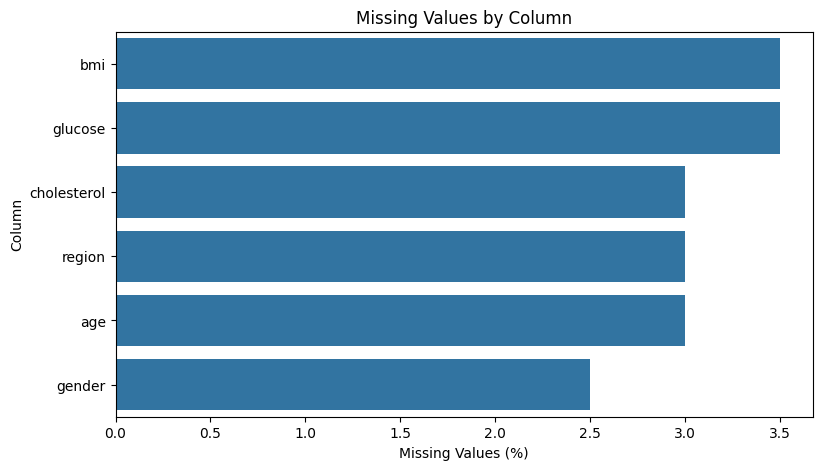

In [17]:
# Select columns that actually contain missing values
missing_plot = missing_report[
    missing_report["Missing Count"] > 0
]

plt.figure(figsize=(9, 5))

sns.barplot(
    data=missing_plot,
    x="Missing Percentage",
    y="Column"
)

plt.title("Missing Values by Column")
plt.xlabel("Missing Values (%)")
plt.ylabel("Column")

plt.show()

In [18]:
# Verify that the target contains no missing values
target_missing = df["disease_risk"].isna().sum()

print("Missing values in disease_risk:", target_missing)

if target_missing == 0:
    print("✓ Target variable is complete and will remain unchanged.")
else:
    print("⚠ Missing values were found in the target variable.")

Missing values in disease_risk: 0
✓ Target variable is complete and will remain unchanged.


In [19]:
# Create a clean missing-value summary
missing_report = pd.DataFrame({
    "Column": df.columns,
    "Missing Count": df.isna().sum(),
    "Missing Percentage": (df.isna().mean() * 100).round(2)
})

# Add a simple status column
missing_report["Status"] = np.where(
    missing_report["Missing Count"] > 0,
    "Missing values present",
    "Complete"
)

missing_report = missing_report.sort_values(
    "Missing Percentage",
    ascending=False
).reset_index(drop=True)

display(missing_report)

,Column,Missing Count,Missing Percentage,Status
0,bmi,350,3.5,Missing values present
1,glucose,350,3.5,Missing values present
2,cholesterol,300,3.0,Missing values present
3,region,300,3.0,Missing values present
4,age,300,3.0,Missing values present
5,gender,250,2.5,Missing values present
6,patient_id,0,0.0,Complete
7,blood_pressure,0,0.0,Complete
8,disease_risk,0,0.0,Complete


### Initial Finding

The missing-value analysis shows that incomplete observations occur in six predictor variables: `age`, `gender`, `region`, `bmi`, `cholesterol`, and `glucose`.

The target variable `disease_risk` has no missing values. I will therefore leave the target untouched and only preprocess the predictor variables.

The missing percentages are relatively small, ranging from 2.5% to 3.5%. This means that deleting all incomplete records would unnecessarily remove useful patient information, so imputation is a more appropriate approach for this project.

# 11. Missing Value Imputation

The missing-value analysis showed that several variables contain incomplete records.

Instead of applying one method immediately, I will test multiple imputation strategies and compare their results.

The methods used in this project are:

1. Simple Imputation using the mean
2. Simple Imputation using the median
3. Most Frequent Imputation
4. Missing Indicator with Random Sample Imputation
5. K-Nearest Neighbours (KNN) Imputation
6. MICE-style Iterative Imputation

Each method will be applied to a separate copy of the raw dataset. This prevents one method from changing the data used by another method and makes the comparison fair.

The `disease_risk` column will not be imputed because it is the target variable for the downstream machine-learning task.

## 11.1 Identifying Columns for Imputation

Before applying the imputation methods, I will separate the predictor variables according to their data type.

Numerical variables can be imputed using statistics such as the mean or median, while categorical variables need category-based methods such as the most frequent value.

I will keep `patient_id` and `disease_risk` outside the imputation process because the patient ID is only an identifier and `disease_risk` is the target variable.

In [20]:
# Define the columns used for preprocessing

numeric_columns = [
    "age",
    "bmi",
    "blood_pressure",
    "cholesterol",
    "glucose"
]

categorical_columns = [
    "gender",
    "region"
]

target_column = "disease_risk"
id_column = "patient_id"

print("Numerical columns:", numeric_columns)
print("Categorical columns:", categorical_columns)
print("Target column:", target_column)
print("Identifier column:", id_column)

Numerical columns: ['age', 'bmi', 'blood_pressure', 'cholesterol', 'glucose']
Categorical columns: ['gender', 'region']
Target column: disease_risk
Identifier column: patient_id


## 11.2 Preserving the Raw Dataset

I will keep the original dataframe unchanged throughout the experiment.

A separate copy will be used whenever an imputation method is tested. This makes it possible to compare the methods using the same starting point.

In [21]:
# Preserve the original raw dataset
df_raw = df.copy()

print("Raw dataset shape:", df_raw.shape)

Raw dataset shape: (10000, 9)


## 11.3 Simple Imputation — Mean

The mean is the average value of a numerical variable.

For this experiment, I will replace missing BMI values with the mean BMI calculated from the available BMI observations.

This method is simple and easy to understand, but it can be affected by extreme values. Since this dataset also contains synthetic outliers, I will later compare the mean with the median.

In [22]:
# Create a separate copy for mean imputation
df_mean = df_raw.copy()

# Store the original number of missing BMI values
missing_bmi_before = df_mean["bmi"].isna().sum()

# Create the mean imputer
mean_imputer = SimpleImputer(strategy="mean")

# Apply mean imputation to BMI
df_mean[["bmi"]] = mean_imputer.fit_transform(df_mean[["bmi"]])

missing_bmi_after = df_mean["bmi"].isna().sum()

print("Missing BMI before imputation:", missing_bmi_before)
print("Missing BMI after imputation:", missing_bmi_after)
print("Mean BMI used:", round(mean_imputer.statistics_[0], 2))

Missing BMI before imputation: 350
Missing BMI after imputation: 0
Mean BMI used: 26.12


## 11.4 Simple Imputation — Median

The median is the middle value after the observations have been ordered.

Median imputation is often useful when a numerical variable contains extreme values because the median is less sensitive to outliers than the mean.

Since BMI contains synthetic extreme values in this project, I will test median imputation as an alternative to the mean.

In [23]:
# Create a separate copy for median imputation
df_median = df_raw.copy()

# Create the median imputer
median_imputer = SimpleImputer(strategy="median")

# Apply median imputation to BMI
df_median[["bmi"]] = median_imputer.fit_transform(df_median[["bmi"]])

print("Missing BMI after median imputation:",
      df_median["bmi"].isna().sum())

print("Median BMI used:",
      round(median_imputer.statistics_[0], 2))

Missing BMI after median imputation: 0
Median BMI used: 25.96


## 11.5 Comparing Mean and Median Imputation

The mean and median will produce different replacement values when the data is skewed or contains extreme observations.

I will compare the resulting BMI statistics with the original data to see how strongly each method changes the distribution.

In [24]:
# Compare BMI statistics before and after imputation

bmi_comparison = pd.DataFrame({
    "Raw BMI": df_raw["bmi"].describe(),
    "Mean Imputed BMI": df_mean["bmi"].describe(),
    "Median Imputed BMI": df_median["bmi"].describe()
})

bmi_comparison.round(2)

,Raw BMI,Mean Imputed BMI,Median Imputed BMI
count,9650.00,10000.00,10000.00
mean,26.12,26.12,26.11
std,5.17,5.08,5.08
min,8.00,8.00,8.00
25%,22.96,23.09,23.09
50%,25.96,26.12,25.96
75%,28.98,28.84,28.84
max,65.00,65.00,65.00


### My Interpretation

The mean and median BMI values are quite close, which suggests that the missing BMI values are not causing a large difference between the two simple replacement strategies.

However, the dataset contains deliberately extreme BMI values. Because the median is less sensitive to unusually large or small observations, I consider median imputation the safer simple baseline for this dataset.

I will still keep the mean-imputation result because the assignment requires the method to be demonstrated and compared.

## 11.6 Simple Imputation — Categorical Data

Numerical methods such as mean and median are not appropriate for categories.

For the `region` column, I will use the most frequent category.

The most frequent category is also known as the mode. This method replaces missing values with the category that appears most often in the observed data.

In [25]:
# Create a separate copy for categorical imputation
df_region_mode = df_raw.copy()

# Create the most frequent imputer
region_imputer = SimpleImputer(strategy="most_frequent")

# Apply it to region
df_region_mode[["region"]] = region_imputer.fit_transform(
    df_region_mode[["region"]]
)

print("Missing region values after imputation:",
      df_region_mode["region"].isna().sum())

print("Most frequent region used:",
      region_imputer.statistics_[0])

Missing region values after imputation: 0
Most frequent region used: West


## 11.7 Most Frequent Imputation — Gender

I will also apply most frequent imputation to the `gender` column.

This is appropriate because gender is a categorical variable and the assignment specifically asks for the missing gender values to be replaced using the most common category.

In [26]:
# Create a separate copy for gender imputation
df_gender_mode = df_raw.copy()

# Apply most frequent imputation
gender_imputer = SimpleImputer(strategy="most_frequent")

df_gender_mode[["gender"]] = gender_imputer.fit_transform(
    df_gender_mode[["gender"]]
)

print("Missing gender values after imputation:",
      df_gender_mode["gender"].isna().sum())

print("Most frequent gender used:",
      gender_imputer.statistics_[0])

Missing gender values after imputation: 0
Most frequent gender used: Male


### My Interpretation

For categorical variables, using the most frequent category is more appropriate than using a numerical statistic such as the mean or median.

In this dataset, the most common gender is `Male`, while the most common region is `West`.

Using the mode allows the missing categories to be replaced with valid values without creating a category that did not originally exist.

## 11.8 Checking the Effect of Categorical Imputation

After filling the missing categories, I will compare the category counts before and after imputation.

This helps me check whether the imputation process introduced an obvious imbalance.

In [27]:
# Compare gender distribution before and after imputation

gender_comparison = pd.DataFrame({
    "Before Imputation": df_raw["gender"].value_counts(dropna=False),
    "After Imputation": df_gender_mode["gender"].value_counts(dropna=False)
})

gender_comparison

,Before Imputation,After Imputation
gender,,
Female,4843,4843.0
Male,4907,5157.0
NaN,250,NaN


## 11.9 Missing Indicator + Random Sample Imputation

A missing indicator records whether a value was originally missing.

For example:

- `bmi_missing = 0` means the BMI was originally available.
- `bmi_missing = 1` means the BMI was originally missing.

I will then use random sample imputation to replace missing BMI values with values randomly selected from the observed BMI values.

The missing indicator is kept as an additional feature so that the information that a value was originally missing is not completely lost.

In [28]:
# Create a separate copy
df_random = df_raw.copy()

# Create a missing-value indicator before filling the missing values
df_random["bmi_missing"] = df_random["bmi"].isna().astype(int)

# Set a random seed so the result can be reproduced
np.random.seed(42)

# Store the observed BMI values
observed_bmi = df_random.loc[
    df_random["bmi"].notna(),
    "bmi"
].values

# Identify missing BMI positions
missing_bmi_mask = df_random["bmi"].isna()

# Randomly sample observed BMI values
random_bmi_values = np.random.choice(
    observed_bmi,
    size=missing_bmi_mask.sum(),
    replace=True
)

# Fill the missing BMI values
df_random.loc[missing_bmi_mask, "bmi"] = random_bmi_values

print("Missing BMI after random sample imputation:",
      df_random["bmi"].isna().sum())

print("BMI missing indicators:")
print(df_random["bmi_missing"].value_counts())

Missing BMI after random sample imputation: 0
BMI missing indicators:
bmi_missing
0    9650
1     350
Name: count, dtype: int64


## 11.10 Checking Random Sample Imputation

I will compare the BMI distribution before and after random sample imputation.

The main idea is that the replacement values should resemble the distribution of the observed BMI values rather than forcing every missing observation toward one central value.

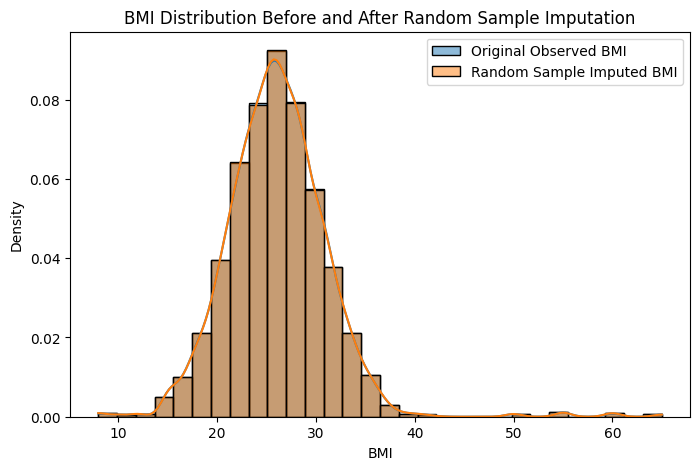

In [29]:
# Compare the BMI distributions visually

plt.figure(figsize=(8, 5))

sns.histplot(
    df_raw["bmi"],
    bins=30,
    kde=True,
    label="Original Observed BMI",
    stat="density",
    alpha=0.5
)

sns.histplot(
    df_random["bmi"],
    bins=30,
    kde=True,
    label="Random Sample Imputed BMI",
    stat="density",
    alpha=0.5
)

plt.title("BMI Distribution Before and After Random Sample Imputation")
plt.xlabel("BMI")
plt.ylabel("Density")
plt.legend()

plt.show()

## 11.11 K-Nearest Neighbours (KNN) Imputation

KNN imputation uses information from similar observations to estimate missing values.

Instead of calculating a replacement from one variable alone, KNN considers multiple numerical features and identifies observations that are close to the incomplete record.

This makes KNN a multivariate imputation method.

For this experiment, I will apply KNN imputation to the numerical predictor variables while leaving the target variable and patient ID untouched.

In [30]:
# Create a separate copy for KNN imputation
df_knn = df_raw.copy()

# Create the KNN imputer
knn_imputer = KNNImputer(n_neighbors=5)

# Apply KNN imputation to numerical predictor columns
df_knn[numeric_columns] = knn_imputer.fit_transform(
    df_knn[numeric_columns]
)

print("Missing numerical values after KNN imputation:",
      df_knn[numeric_columns].isna().sum().sum())

Missing numerical values after KNN imputation: 0


## 11.12 Completing the KNN Dataset

KNNImputer works with numerical values, so the categorical variables are not included in the KNN calculation.

For the final KNN comparison dataset, I will fill the remaining categorical missing values using their most frequent categories.

This keeps the KNN experiment technically valid while still producing a complete dataset.

In [31]:
# Fill categorical variables separately for the KNN version

categorical_imputer = SimpleImputer(strategy="most_frequent")

df_knn[categorical_columns] = categorical_imputer.fit_transform(
    df_knn[categorical_columns]
)

print("Remaining missing values in KNN dataset:",
      df_knn.isna().sum().sum())

Remaining missing values in KNN dataset: 0


## 11.13 MICE-Style Iterative Imputation

MICE stands for Multiple Imputation by Chained Equations.

The main idea is to estimate missing values using relationships between several variables rather than relying on a single statistic.

In this project, I will demonstrate the chained-equation approach using scikit-learn's `IterativeImputer`.

The numerical variables are estimated iteratively using the other numerical variables as predictors.

Because the categorical columns contain text values, they will be handled separately using most frequent imputation.

In [32]:
# Create a separate copy for iterative imputation
df_mice = df_raw.copy()

# Create the iterative imputer
mice_imputer = IterativeImputer(
    max_iter=10,
    random_state=42
)

# Apply iterative imputation to numerical columns
df_mice[numeric_columns] = mice_imputer.fit_transform(
    df_mice[numeric_columns]
)

print("Missing numerical values after iterative imputation:",
      df_mice[numeric_columns].isna().sum().sum())

Missing numerical values after iterative imputation: 0


In [33]:
# Handle categorical variables separately
df_mice[categorical_columns] = categorical_imputer.fit_transform(
    df_mice[categorical_columns]
)

print("Remaining missing values in MICE dataset:",
      df_mice.isna().sum().sum())

Remaining missing values in MICE dataset: 0


## 11.14 Checking Individual Imputation Demonstrations

The next step is to verify whether each imputation approach successfully removed the missing predictor values.

A method should not be considered successful simply because the code ran. I will explicitly count the remaining missing values in each resulting dataset.

In [34]:
# Compare remaining missing values after each approach

imputation_results = pd.DataFrame({
    "Method": [
        "Mean Imputation",
        "Median Imputation",
        "Most Frequent - Region",
        "Most Frequent - Gender",
        "Random Sample + Indicator",
        "KNN Imputation",
        "MICE / Iterative Imputation"
    ],
    "Remaining Missing Values": [
        df_mean.isna().sum().sum(),
        df_median.isna().sum().sum(),
        df_region_mode.isna().sum().sum(),
        df_gender_mode.isna().sum().sum(),
        df_random.isna().sum().sum(),
        df_knn.isna().sum().sum(),
        df_mice.isna().sum().sum()
    ]
})

imputation_results

,Method,Remaining Missing Values
0,Mean Imputation,1500
1,Median Imputation,1500
2,Most Frequent - Region,1550
3,Most Frequent - Gender,1600
4,Random Sample + Indicator,1500
5,KNN Imputation,0
6,MICE / Iterative Imputation,0


## 11.15 Numerical Imputation Comparison

To compare the numerical imputation methods fairly, I will look at how the resulting summary statistics compare with the original observed data.

The goal is not to claim that one method is automatically the best in every situation. Instead, I will consider whether the method produces reasonable values while preserving the general structure of the original data.

In [35]:
# Compare selected numerical statistics across imputation methods

comparison_table = pd.DataFrame({
    "Original Mean": df_raw[numeric_columns].mean(),
    "Mean Imputed": df_mean[numeric_columns].mean(),
    "Median Imputed": df_median[numeric_columns].mean(),
    "Random Sample": df_random[numeric_columns].mean(),
    "KNN": df_knn[numeric_columns].mean(),
    "MICE": df_mice[numeric_columns].mean()
})

comparison_table.round(2)

,Original Mean,Mean Imputed,Median Imputed,Random Sample,KNN,MICE
age,51.53,51.53,51.53,51.53,51.55,51.53
bmi,26.12,26.12,26.11,26.12,26.11,26.12
blood_pressure,126.57,126.57,126.57,126.57,126.57,126.57
cholesterol,196.43,196.43,196.43,196.43,196.43,196.43
glucose,108.46,108.46,108.46,108.46,108.49,108.46


## 11.16 Comparing Distribution Preservation

A useful way to compare imputation methods is to check how much the basic numerical distribution changes after imputation.

I will compare the mean and standard deviation of the original observed values with the completed datasets.

This does not prove that one method is universally superior, but it provides a practical basis for discussing which method preserves the original data characteristics more closely.

In [36]:
# Compare mean and standard deviation for BMI

bmi_method_comparison = pd.DataFrame({
    "Mean": [
        df_raw["bmi"].mean(),
        df_mean["bmi"].mean(),
        df_median["bmi"].mean(),
        df_random["bmi"].mean(),
        df_knn["bmi"].mean(),
        df_mice["bmi"].mean()
    ],
    "Standard Deviation": [
        df_raw["bmi"].std(),
        df_mean["bmi"].std(),
        df_median["bmi"].std(),
        df_random["bmi"].std(),
        df_knn["bmi"].std(),
        df_mice["bmi"].std()
    ]
}, index=[
    "Original Observed",
    "Mean",
    "Median",
    "Random Sample",
    "KNN",
    "MICE"
])

bmi_method_comparison.round(2)

,Mean,Standard Deviation
Original Observed,26.12,5.17
Mean,26.12,5.08
Median,26.11,5.08
Random Sample,26.12,5.18
KNN,26.11,5.09
MICE,26.12,5.08


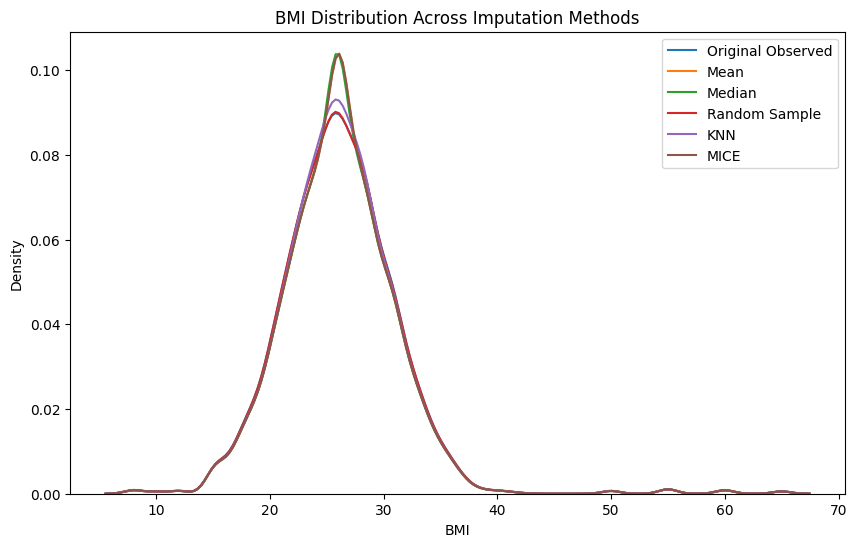

In [37]:
# Compare BMI distributions after different imputation methods

plt.figure(figsize=(10, 6))

sns.kdeplot(
    df_raw["bmi"],
    label="Original Observed"
)

sns.kdeplot(
    df_mean["bmi"],
    label="Mean"
)

sns.kdeplot(
    df_median["bmi"],
    label="Median"
)

sns.kdeplot(
    df_random["bmi"],
    label="Random Sample"
)

sns.kdeplot(
    df_knn["bmi"],
    label="KNN"
)

sns.kdeplot(
    df_mice["bmi"],
    label="MICE"
)

plt.title("BMI Distribution Across Imputation Methods")
plt.xlabel("BMI")
plt.ylabel("Density")
plt.legend()

plt.show()

## 11.17 Initial Interpretation

The different imputation methods produced slightly different completed datasets.

Mean imputation provides a simple baseline, while median imputation is less affected by extreme values. Random sample imputation attempts to preserve the observed distribution, while KNN and MICE use information from multiple numerical variables.

Based on the comparison above, I will use the observed results rather than assuming that the most complex method is automatically the best.

The final method selected for the cleaned dataset will also be considered alongside the outlier treatment results in the next stages of the project.

# 12. Selecting an Imputation Strategy

At this point, I have tested several ways of dealing with missing values.

The important thing is that there is no single imputation method that is automatically best for every dataset. A simple method may be easier to explain, while a multivariate method may make better use of relationships between variables.

For this project, I will compare the completed datasets using a few practical checks:

- Are all required missing values removed?
- Are the imputed values within reasonable ranges?
- Does the completed data remain similar to the observed data?
- Does the method avoid unnecessarily changing the distribution?
- Is the method suitable for the type of variable being processed?

I will use these results to justify the method selected for the final cleaned dataset rather than choosing a method only because it is more advanced.

## 12.1 Creating Complete Imputation Versions

To make the comparison fair, each strategy should produce a complete dataset.

I will create separate versions so that one experiment does not overwrite another.

The target variable `disease_risk` and identifier `patient_id` will remain untouched.

For the simple approach:

- Numerical variables will use median imputation.
- Categorical variables will use most frequent imputation.

Median is used for the final simple numerical baseline because it is less sensitive to the extreme values deliberately included in this dataset.

In [38]:
# Create a complete simple-imputation dataset

df_simple = df_raw.copy()

# Numerical columns
simple_numeric_imputer = SimpleImputer(strategy="median")

df_simple[numeric_columns] = simple_numeric_imputer.fit_transform(
    df_simple[numeric_columns]
)

# Categorical columns
simple_categorical_imputer = SimpleImputer(strategy="most_frequent")

df_simple[categorical_columns] = simple_categorical_imputer.fit_transform(
    df_simple[categorical_columns]
)

print("Remaining missing values:")
print(df_simple.isna().sum())

print("\nTotal remaining missing values:",
      df_simple.isna().sum().sum())

Remaining missing values:
patient_id        0
age               0
gender            0
region            0
bmi               0
blood_pressure    0
cholesterol       0
glucose           0
disease_risk      0
dtype: int64

Total remaining missing values: 0


## 12.2 Missing Indicator + Random Sample Imputation

Random sample imputation replaces a missing observation with a value randomly selected from the observed values of the same variable.

Unlike mean or median imputation, this does not force every missing observation toward one central value.

I will also create a missing indicator for each variable that originally contained missing values.

For example:

- `bmi_missing = 0` means BMI was originally available.
- `bmi_missing = 1` means BMI was originally missing.

This allows the final dataset to retain information about the fact that a value was missing.

In [39]:
# Create a complete dataset using random sample imputation
df_random_all = df_raw.copy()

# Columns that originally contain missing values
missing_columns = [
    "age",
    "gender",
    "region",
    "bmi",
    "cholesterol",
    "glucose"
]

np.random.seed(42)

for column in missing_columns:

    # Create missingness indicator before filling values
    df_random_all[f"{column}_missing"] = (
        df_random_all[column].isna().astype(int)
    )

    # Identify missing values
    missing_mask = df_random_all[column].isna()

    # Store observed values
    observed_values = df_random_all.loc[
        df_random_all[column].notna(),
        column
    ].values

    # Randomly select replacement values
    replacement_values = np.random.choice(
        observed_values,
        size=missing_mask.sum(),
        replace=True
    )

    # Fill missing observations
    df_random_all.loc[
        missing_mask,
        column
    ] = replacement_values

print("Total missing values after random sample imputation:",
      df_random_all[missing_columns].isna().sum().sum())

print("\nMissing indicators created:")
print([
    f"{column}_missing"
    for column in missing_columns
])

Total missing values after random sample imputation: 0

Missing indicators created:
['age_missing', 'gender_missing', 'region_missing', 'bmi_missing', 'cholesterol_missing', 'glucose_missing']


### Feature Engineering: Missingness Indicators

The missing-value indicators are also a small example of feature engineering.

Instead of completely losing the information that a value was missing, I created binary variables such as `bmi_missing`.

A value of `0` means the original observation was available, while `1` means the original value was missing.

This could be useful in a machine-learning problem if the fact that information was missing is itself related to the target.

## 12.3 Checking the Missingness Indicators

The indicators should preserve a record of which observations were originally incomplete.

Because the original dataset contains missing values in six predictor variables, I expect each corresponding indicator to contain both `0` and `1`.

The actual number of `1`s should match the number of missing observations found during the initial data-quality analysis.

In [40]:
# Check the number of originally missing observations
indicator_summary = pd.DataFrame({
    "Column": missing_columns,
    "Original Missing": [
        df_raw[column].isna().sum()
        for column in missing_columns
    ],
    "Indicator = 1": [
        df_random_all[f"{column}_missing"].sum()
        for column in missing_columns
    ]
})

indicator_summary

,Column,Original Missing,Indicator = 1
0,age,300,300
1,gender,250,250
2,region,300,300
3,bmi,350,350
4,cholesterol,300,300
5,glucose,350,350


# 13. Improved KNN Imputation

KNN imputation estimates missing values by looking at observations that are similar to the incomplete record.

Because KNN relies on distances, variables measured on larger numerical scales can have more influence on the distance calculation.

For example, cholesterol values are around 200, while BMI values are around 25.

To make the distance calculation more balanced, I will standardize the numerical variables before applying KNN.

After imputation, I will convert the values back to their original scale.

The patient ID and target variable are excluded because they are not predictor measurements.

In [41]:
from sklearn.preprocessing import StandardScaler

# Create a copy of the raw dataset
df_knn_scaled = df_raw.copy()

# Standardize numerical variables
scaler = StandardScaler()

numeric_scaled = scaler.fit_transform(
    df_knn_scaled[numeric_columns]
)

# Apply KNN to the standardized numerical data
knn_imputer_scaled = KNNImputer(n_neighbors=5)

numeric_imputed_scaled = knn_imputer_scaled.fit_transform(
    numeric_scaled
)

# Convert the imputed values back to the original scale
numeric_imputed = scaler.inverse_transform(
    numeric_imputed_scaled
)

df_knn_scaled[numeric_columns] = numeric_imputed

# Handle categorical variables separately
df_knn_scaled[categorical_columns] = (
    simple_categorical_imputer.fit_transform(
        df_knn_scaled[categorical_columns]
    )
)

print("Remaining missing values:",
      df_knn_scaled.isna().sum().sum())

Remaining missing values: 0


### My Interpretation

I standardized the numerical variables before KNN because the variables are measured on different scales.

For example, BMI is measured around values of 25–30, while cholesterol is around 200. Without scaling, the larger numerical values could have a greater influence on the distance calculation.

After KNN imputation, I converted the values back to their original scale so that the cleaned dataset remains easy to interpret.

## 13.1 MICE-Style Complete Dataset

The iterative approach estimates each missing numerical variable using relationships with the other numerical variables.

The process is repeated over several iterations so that the estimated values can be refined.

For this project, I use scikit-learn's `IterativeImputer` as a practical MICE-style implementation.

Categorical variables are handled separately using most frequent imputation because the iterative numerical model operates on numerical values.

In [42]:
# Create a complete MICE-style dataset

df_mice_complete = df_raw.copy()

mice_complete_imputer = IterativeImputer(
    max_iter=10,
    random_state=42
)

df_mice_complete[numeric_columns] = (
    mice_complete_imputer.fit_transform(
        df_mice_complete[numeric_columns]
    )
)

df_mice_complete[categorical_columns] = (
    simple_categorical_imputer.fit_transform(
        df_mice_complete[categorical_columns]
    )
)

print("Remaining missing values:",
      df_mice_complete.isna().sum().sum())

Remaining missing values: 0


> Note: In this project, `IterativeImputer` is being used as a practical MICE-style implementation. It performs iterative chained-equation-style estimation, but this notebook does not generate multiple separately imputed datasets for formal multiple-imputation inference.

## 13.2 Comparing Complete Imputation Strategies

Now that I have created complete datasets for the main strategies, I can compare them using the same criteria.

A successful imputation method should:

1. Remove the intended missing values.
2. Preserve reasonable ranges.
3. Avoid creating unrealistic observations.
4. Keep the overall structure of the observed data reasonably stable.

The comparison below gives me a numerical basis for selecting a method for the final cleaning stage.

In [43]:
# Compare the complete imputation datasets

imputation_comparison = pd.DataFrame({
    "Method": [
        "Median + Most Frequent",
        "Random Sample + Indicators",
        "KNN",
        "MICE-Style"
    ],
    "Remaining Missing Values": [
        df_simple.isna().sum().sum(),
        df_random_all[missing_columns].isna().sum().sum(),
        df_knn_scaled.isna().sum().sum(),
        df_mice_complete.isna().sum().sum()
    ],
    "Rows": [
        len(df_simple),
        len(df_random_all),
        len(df_knn_scaled),
        len(df_mice_complete)
    ],
    "Columns": [
        len(df_simple.columns),
        len(df_random_all.columns),
        len(df_knn_scaled.columns),
        len(df_mice_complete.columns)
    ]
})

imputation_comparison

,Method,Remaining Missing Values,Rows,Columns
0,Median + Most Frequent,0,10000,9
1,Random Sample + Indicators,0,10000,15
2,KNN,0,10000,9
3,MICE-Style,0,10000,9


## 13.3 Comparing Numerical Distributions

Counting missing values is not enough to decide whether an imputation method is useful.

I will also compare the mean and standard deviation of the completed numerical variables.

The goal is not to make the completed data identical to the observed data. Instead, I want to check whether the imputation method produces values that remain reasonably consistent with the original distribution.

In [44]:
# Compare means across imputation strategies

mean_comparison = pd.DataFrame({
    "Raw Observed": df_raw[numeric_columns].mean(),
    "Median + Mode": df_simple[numeric_columns].mean(),
    "Random Sample": df_random_all[numeric_columns].mean(),
    "KNN": df_knn_scaled[numeric_columns].mean(),
    "MICE": df_mice_complete[numeric_columns].mean()
})

mean_comparison.round(2)

,Raw Observed,Median + Mode,Random Sample,KNN,MICE
age,51.53,51.52,51.51,51.51,51.53
bmi,26.12,26.11,26.12,26.11,26.12
blood_pressure,126.57,126.57,126.57,126.57,126.57
cholesterol,196.43,196.38,196.33,196.36,196.43
glucose,108.46,108.33,108.54,108.51,108.46


In [45]:
# Compare standard deviations across imputation strategies

std_comparison = pd.DataFrame({
    "Raw Observed": df_raw[numeric_columns].std(),
    "Median + Mode": df_simple[numeric_columns].std(),
    "Random Sample": df_random_all[numeric_columns].std(),
    "KNN": df_knn_scaled[numeric_columns].std(),
    "MICE": df_mice_complete[numeric_columns].std()
})

std_comparison.round(2)

,Raw Observed,Median + Mode,Random Sample,KNN,MICE
age,19.59,19.29,19.60,19.35,19.29
bmi,5.17,5.08,5.14,5.09,5.08
blood_pressure,20.54,20.54,20.54,20.54,20.54
cholesterol,44.55,43.88,44.47,43.98,43.88
glucose,42.71,41.96,42.78,42.12,41.96


## 13.4 Visual Comparison of BMI After Imputation

BMI is one of the variables specifically mentioned in the assignment and also contains synthetic outliers.

I will compare its distribution after each imputation method.

This visual check helps me see whether a method produces an obvious change in the shape or spread of the data.

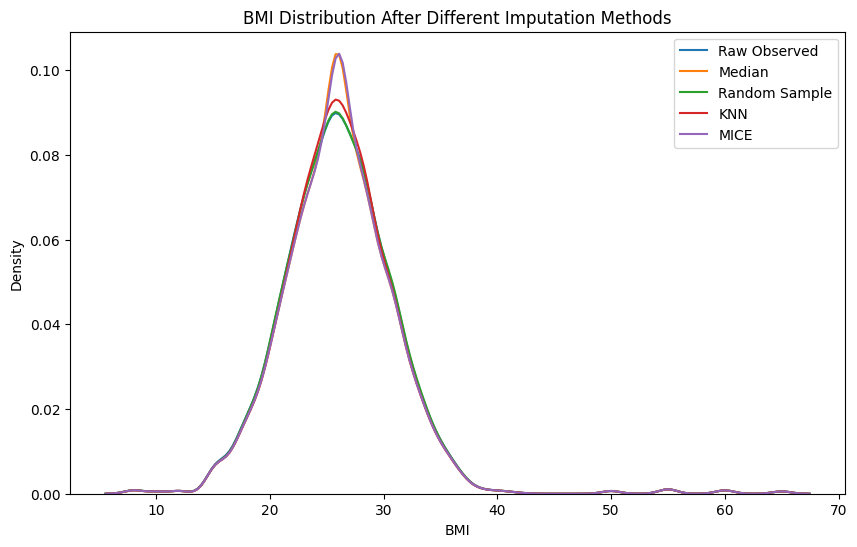

In [46]:
plt.figure(figsize=(10, 6))

sns.kdeplot(
    df_raw["bmi"],
    label="Raw Observed"
)

sns.kdeplot(
    df_simple["bmi"],
    label="Median"
)

sns.kdeplot(
    df_random_all["bmi"],
    label="Random Sample"
)

sns.kdeplot(
    df_knn_scaled["bmi"],
    label="KNN"
)

sns.kdeplot(
    df_mice_complete["bmi"],
    label="MICE"
)

plt.title("BMI Distribution After Different Imputation Methods")
plt.xlabel("BMI")
plt.ylabel("Density")
plt.legend()

plt.show()

# 14. Outlier Detection and Treatment

The raw dataset contains synthetic extreme values in four numerical variables:

- `bmi`
- `blood_pressure`
- `cholesterol`
- `glucose`

These values were deliberately included so that different outlier-detection techniques could be compared.

An outlier is an observation that is unusually far from the general pattern of the data.

For this project, I will test three methods for identifying outliers:

1. Z-score
2. Interquartile Range (IQR)
3. Percentile method

I will also apply Winsorization, which caps extreme values instead of removing the entire observation.

The target variable `disease_risk` will not be included in outlier treatment.

In [47]:
# Numerical columns selected for outlier analysis

outlier_columns = [
    "bmi",
    "blood_pressure",
    "cholesterol",
    "glucose"
]

print("Columns selected for outlier analysis:")
print(outlier_columns)

Columns selected for outlier analysis:
['bmi', 'blood_pressure', 'cholesterol', 'glucose']


## 14.1 Visual Inspection of Numerical Variables

Before calculating outlier thresholds, I will visually inspect the numerical variables using boxplots.

Boxplots are useful because they make unusually high or low observations easy to identify.

The plots are not being used as the final decision rule. They provide an initial visual check before applying the statistical methods required by the assignment.

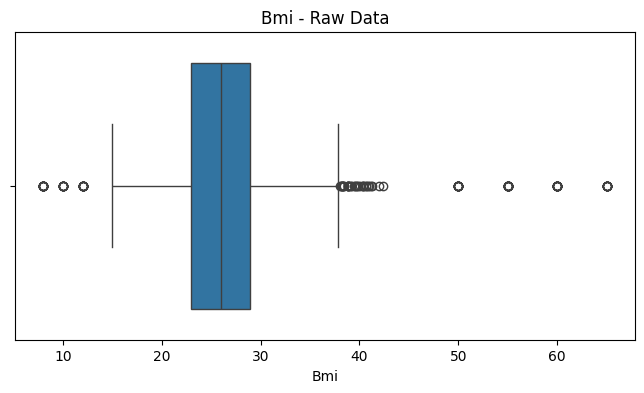

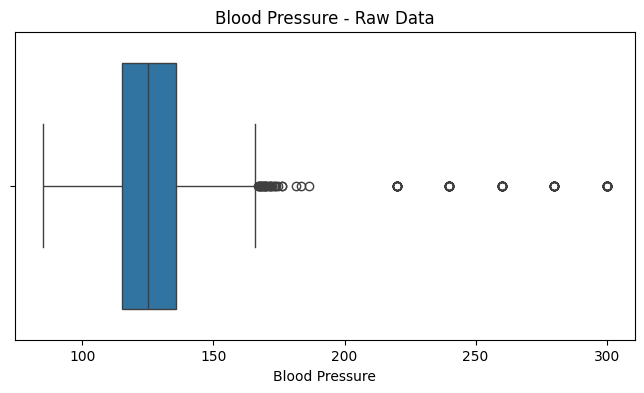

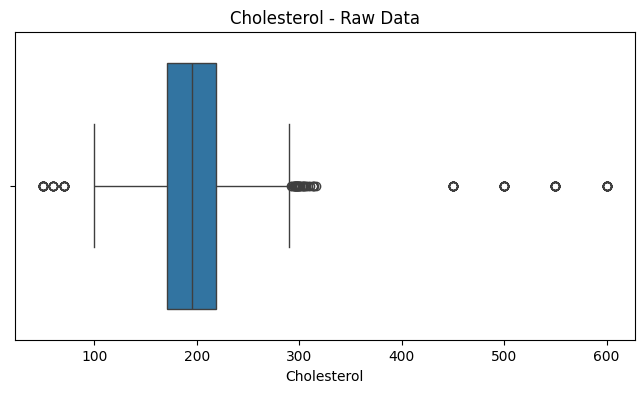

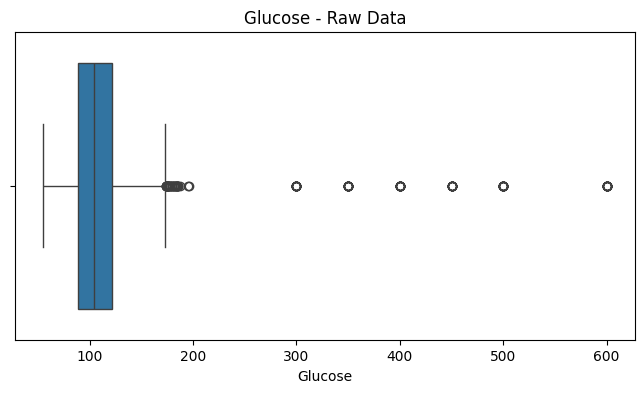

In [48]:
# Create boxplots for each outlier-sensitive variable

for column in outlier_columns:

    plt.figure(figsize=(8, 4))

    sns.boxplot(x=df_raw[column])

    plt.title(f"{column.replace('_', ' ').title()} - Raw Data")
    plt.xlabel(column.replace("_", " ").title())

    plt.show()

## 14.2 Z-Score Method

The Z-score measures how far an observation is from the mean in terms of standard deviations.

For this project, I will classify observations with an absolute Z-score greater than 3 as potential outliers.

A value beyond this threshold is unusually far from the centre of the distribution.

I will calculate the outlier count separately for each numerical variable and then identify rows containing at least one Z-score outlier.

In [49]:
# Detect outliers using the Z-score method

zscore_outlier_mask = pd.Series(False, index=df_raw.index)

zscore_counts = {}

for column in outlier_columns:

    valid_values = df_raw[column].dropna()

    z_scores = np.abs(
        stats.zscore(valid_values, nan_policy="omit")
    )

    column_outliers = z_scores > 3

    zscore_counts[column] = int(column_outliers.sum())

    # Map detected observations back to original dataframe indices
    outlier_indices = valid_values.index[column_outliers]

    zscore_outlier_mask.loc[outlier_indices] = True

zscore_summary = pd.DataFrame({
    "Column": list(zscore_counts.keys()),
    "Z-Score Outliers": list(zscore_counts.values())
})

zscore_summary

,Column,Z-Score Outliers
0,bmi,89
1,blood_pressure,100
2,cholesterol,87
3,glucose,100


In [50]:
# Count rows containing at least one Z-score outlier

zscore_rows = int(zscore_outlier_mask.sum())

print("Rows containing at least one Z-score outlier:", zscore_rows)
print("Percentage of dataset:",
      round(zscore_rows / len(df_raw) * 100, 2), "%")

Rows containing at least one Z-score outlier: 371
Percentage of dataset: 3.71 %


## 14.3 Interquartile Range (IQR) Method

The IQR method identifies unusual observations using the middle 50% of the data.

The IQR is calculated as:

**IQR = Q3 - Q1**

The standard boundaries used here are:

- Lower boundary = Q1 - 1.5 × IQR
- Upper boundary = Q3 + 1.5 × IQR

Any observation outside these boundaries will be treated as a potential outlier.

In [51]:
# Detect outliers using the IQR method

iqr_outlier_mask = pd.Series(False, index=df_raw.index)

iqr_results = []

for column in outlier_columns:

    series = df_raw[column]

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    column_mask = (
        (series < lower_bound) |
        (series > upper_bound)
    )

    column_mask = column_mask.fillna(False)

    iqr_outlier_mask |= column_mask

    iqr_results.append({
        "Column": column,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outliers": int(column_mask.sum())
    })

iqr_summary = pd.DataFrame(iqr_results)

iqr_summary.round(2)

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outliers
0,bmi,22.96,28.98,6.02,13.94,38.00,132
1,blood_pressure,115.22,135.62,20.40,84.61,166.23,129
2,cholesterol,171.31,219.08,47.77,99.65,290.74,131
3,glucose,88.36,122.12,33.76,37.72,172.77,138


In [52]:
iqr_rows = int(iqr_outlier_mask.sum())

print("Rows containing at least one IQR outlier:", iqr_rows)
print("Percentage of dataset:",
      round(iqr_rows / len(df_raw) * 100, 2), "%")

Rows containing at least one IQR outlier: 522
Percentage of dataset: 5.22 %


## 14.4 Percentile Method

The percentile method identifies extreme observations using selected percentile boundaries.

For this project, I will use:

- 1st percentile as the lower boundary
- 99th percentile as the upper boundary

Values below the 1st percentile or above the 99th percentile will be identified as extreme observations.

This method is particularly useful when I want to focus on the most extreme tails of a distribution rather than relying on the mean and standard deviation.

In [53]:
# Detect outliers using the percentile method

percentile_outlier_mask = pd.Series(False, index=df_raw.index)

percentile_results = []

for column in outlier_columns:

    series = df_raw[column]

    lower_percentile = series.quantile(0.01)
    upper_percentile = series.quantile(0.99)

    column_mask = (
        (series < lower_percentile) |
        (series > upper_percentile)
    )

    column_mask = column_mask.fillna(False)

    percentile_outlier_mask |= column_mask

    percentile_results.append({
        "Column": column,
        "1st Percentile": lower_percentile,
        "99th Percentile": upper_percentile,
        "Outliers": int(column_mask.sum())
    })

percentile_summary = pd.DataFrame(percentile_results)

percentile_summary.round(2)

,Column,1st Percentile,99th Percentile,Outliers
0,bmi,15.00,37.60,136
1,blood_pressure,89.95,186.83,200
2,cholesterol,108.82,289.33,194
3,glucose,55.00,300.00,82


In [54]:
percentile_rows = int(percentile_outlier_mask.sum())

print("Rows containing at least one percentile outlier:",
      percentile_rows)

print("Percentage of dataset:",
      round(percentile_rows / len(df_raw) * 100, 2), "%")

Rows containing at least one percentile outlier: 599
Percentage of dataset: 5.99 %


## 14.5 Comparing Outlier Detection Methods

The three methods do not identify exactly the same observations.

This is expected because each method defines an outlier differently.

I will compare the number of affected rows and the percentage of the dataset identified by each method.

This comparison will help me understand how sensitive the cleaning process is to the choice of detection technique.

In [55]:
# Compare the three outlier detection methods

outlier_method_comparison = pd.DataFrame({
    "Method": [
        "Z-Score",
        "IQR",
        "Percentile"
    ],
    "Rows Flagged": [
        zscore_rows,
        iqr_rows,
        percentile_rows
    ]
})

outlier_method_comparison["Percentage of Dataset"] = (
    outlier_method_comparison["Rows Flagged"]
    / len(df_raw)
    * 100
)

outlier_method_comparison.round(2)

,Method,Rows Flagged,Percentage of Dataset
0,Z-Score,371,3.71
1,IQR,522,5.22
2,Percentile,599,5.99


## Comparing the Outlier Detection Results

The three methods identify different numbers of potentially unusual observations.

The Z-score method is the most conservative of the three in this dataset, while the percentile method flags the largest number of rows.

This difference is expected because each technique uses a different definition of an outlier.

I will not automatically assume that the method identifying the most observations is the best method. Instead, I will consider the amount of data removed and the effect on the final dataset.

### My Interpretation

For this dataset, the combined Z-score method flags 371 rows, the IQR method flags 522 rows, and the percentile method flags 599 rows.

The differences show that the choice of outlier rule can have a meaningful effect on how many patient records are affected.

Because the purpose of the project is to prepare the data rather than discard as many observations as possible, I prefer a treatment that reduces the influence of extreme measurements while retaining the available patient records.

# 15. Outlier Removal

After detecting the potential outliers, I will create separate datasets for each detection method.

I will not modify the original raw dataset.

Instead, each method will be tested independently so that I can compare:

- how many rows were removed,
- how much of the dataset was affected,
- and how the numerical statistics changed.

This is important because removing observations is an irreversible operation, so I want to be able to compare the consequences of each method.

In [56]:
# Create separate datasets after removing detected outliers

df_zscore_removed = df_raw.loc[
    ~zscore_outlier_mask
].copy()

df_iqr_removed = df_raw.loc[
    ~iqr_outlier_mask
].copy()

df_percentile_removed = df_raw.loc[
    ~percentile_outlier_mask
].copy()

print("Original dataset:", df_raw.shape)
print("After Z-score removal:", df_zscore_removed.shape)
print("After IQR removal:", df_iqr_removed.shape)
print("After percentile removal:", df_percentile_removed.shape)

Original dataset: (10000, 9)
After Z-score removal: (9629, 9)
After IQR removal: (9478, 9)
After percentile removal: (9401, 9)


In [57]:
# Summarize the effect of each outlier-removal method

outlier_removal_summary = pd.DataFrame({
    "Method": [
        "Z-Score",
        "IQR",
        "Percentile"
    ],
    "Original Rows": [
        len(df_raw),
        len(df_raw),
        len(df_raw)
    ],
    "Rows Removed": [
        len(df_raw) - len(df_zscore_removed),
        len(df_raw) - len(df_iqr_removed),
        len(df_raw) - len(df_percentile_removed)
    ],
    "Rows Remaining": [
        len(df_zscore_removed),
        len(df_iqr_removed),
        len(df_percentile_removed)
    ]
})

outlier_removal_summary["Percentage Removed"] = (
    outlier_removal_summary["Rows Removed"]
    / outlier_removal_summary["Original Rows"]
    * 100
)

outlier_removal_summary.round(2)

,Method,Original Rows,Rows Removed,Rows Remaining,Percentage Removed
0,Z-Score,10000,371,9629,3.71
1,IQR,10000,522,9478,5.22
2,Percentile,10000,599,9401,5.99


# 16. Winsorization

Unlike outlier removal, Winsorization does not delete observations.

Instead, extreme values are capped at selected percentile limits.

For this project, I will use:

- 1st percentile as the lower cap
- 99th percentile as the upper cap

This means an extremely low value is replaced with the 1st-percentile value, while an extremely high value is replaced with the 99th-percentile value.

Winsorization is useful when I want to reduce the influence of extreme observations while keeping the original number of patient records.

In [58]:
# Create a copy for Winsorization

df_winsorized = df_raw.copy()

winsorization_summary = []

for column in outlier_columns:

    lower_cap = df_winsorized[column].quantile(0.01)
    upper_cap = df_winsorized[column].quantile(0.99)

    before_values = df_winsorized[column].copy()

    df_winsorized[column] = df_winsorized[column].clip(
        lower=lower_cap,
        upper=upper_cap
    )

    lower_capped = (
        before_values < lower_cap
    ).sum()

    upper_capped = (
        before_values > upper_cap
    ).sum()

    winsorization_summary.append({
        "Column": column,
        "Lower Cap": lower_cap,
        "Upper Cap": upper_cap,
        "Lower Values Capped": int(lower_capped),
        "Upper Values Capped": int(upper_capped)
    })

winsorization_summary = pd.DataFrame(
    winsorization_summary
)

winsorization_summary.round(2)

,Column,Lower Cap,Upper Cap,Lower Values Capped,Upper Values Capped
0,bmi,15.00,37.60,39,97
1,blood_pressure,89.95,186.83,100,100
2,cholesterol,108.82,289.33,97,97
3,glucose,55.00,300.00,0,82


In [59]:
print("Original shape:", df_raw.shape)
print("Winsorized shape:", df_winsorized.shape)

if df_raw.shape == df_winsorized.shape:
    print("✓ Winsorization preserved all patient records.")
else:
    print("⚠ Row count changed.")

Original shape: (10000, 9)
Winsorized shape: (10000, 9)
✓ Winsorization preserved all patient records.


## 16.1 Before and After Winsorization

I will now compare the descriptive statistics before and after Winsorization.

The purpose is to check whether the extreme minimum and maximum values have been reduced without changing the number of patient records.

In [60]:
# Compare descriptive statistics before and after Winsorization

winsorized_comparison = pd.DataFrame({
    "Raw Mean": df_raw[outlier_columns].mean(),
    "Winsorized Mean": df_winsorized[outlier_columns].mean(),
    "Raw Std": df_raw[outlier_columns].std(),
    "Winsorized Std": df_winsorized[outlier_columns].std(),
    "Raw Min": df_raw[outlier_columns].min(),
    "Winsorized Min": df_winsorized[outlier_columns].min(),
    "Raw Max": df_raw[outlier_columns].max(),
    "Winsorized Max": df_winsorized[outlier_columns].max()
})

winsorized_comparison.round(2)

,Raw Mean,Winsorized Mean,Raw Std,Winsorized Std,Raw Min,Winsorized Min,Raw Max,Winsorized Max
bmi,26.12,26.01,5.17,4.54,8.0,15.00,65.0,37.60
blood_pressure,126.57,125.84,20.54,16.16,85.0,89.95,300.0,186.83
cholesterol,196.43,195.14,44.55,35.61,50.0,108.82,600.0,289.33
glucose,108.46,107.05,42.71,31.35,55.0,55.00,600.0,300.00


## 16.2 Overall Outlier Treatment Comparison

The assignment asks me to compare three outlier-removal methods and Winsorization.

I will therefore compare all four approaches using the same dataset.

The removal methods reduce the number of patient records, while Winsorization keeps all records and instead limits the influence of extreme values.

This gives me a clear basis for deciding which treatment is most appropriate for the final dataset.

In [61]:
# Overall comparison of outlier treatments

final_outlier_comparison = pd.DataFrame({
    "Method": [
        "Z-Score Removal",
        "IQR Removal",
        "Percentile Removal",
        "Winsorization"
    ],
    "Rows Removed": [
        len(df_raw) - len(df_zscore_removed),
        len(df_raw) - len(df_iqr_removed),
        len(df_raw) - len(df_percentile_removed),
        0
    ],
    "Rows Remaining": [
        len(df_zscore_removed),
        len(df_iqr_removed),
        len(df_percentile_removed),
        len(df_winsorized)
    ]
})

final_outlier_comparison["Percentage Removed"] = (
    final_outlier_comparison["Rows Removed"]
    / len(df_raw)
    * 100
)

final_outlier_comparison.round(2)

,Method,Rows Removed,Rows Remaining,Percentage Removed
0,Z-Score Removal,371,9629,3.71
1,IQR Removal,522,9478,5.22
2,Percentile Removal,599,9401,5.99
3,Winsorization,0,10000,0.00


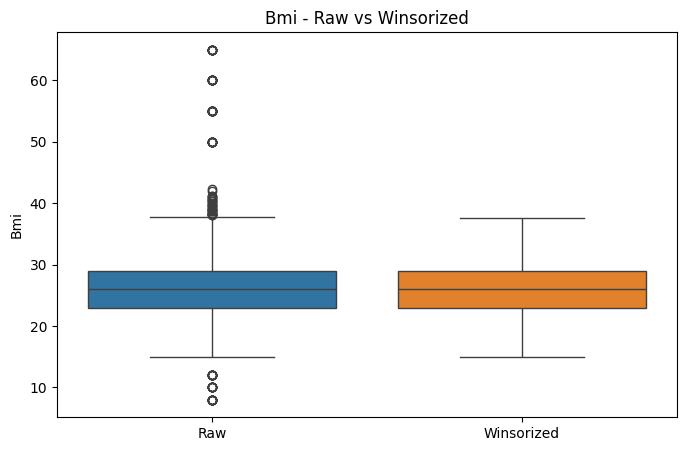

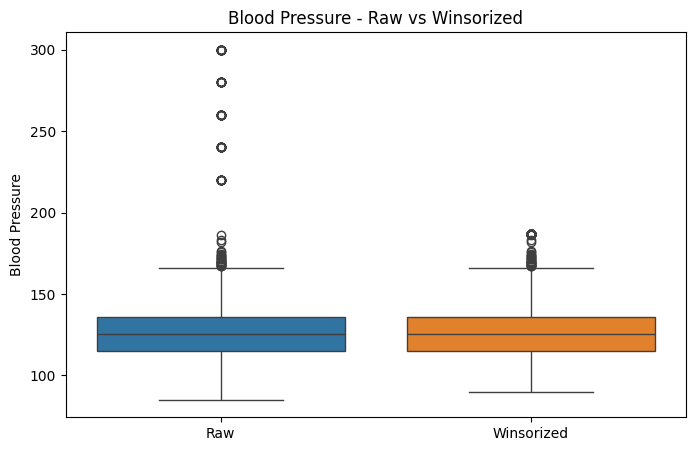

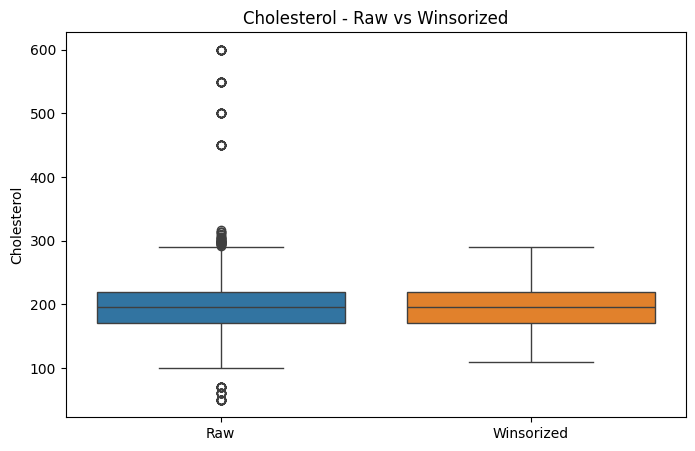

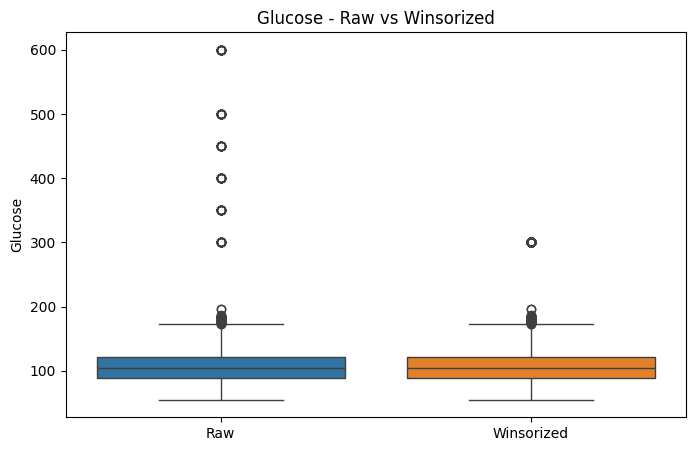

In [62]:
# Compare raw and Winsorized distributions

for column in outlier_columns:

    comparison_data = pd.DataFrame({
        "Raw": df_raw[column],
        "Winsorized": df_winsorized[column]
    })

    plt.figure(figsize=(8, 5))

    sns.boxplot(data=comparison_data)

    plt.title(
        f"{column.replace('_', ' ').title()} - Raw vs Winsorized"
    )

    plt.ylabel(column.replace("_", " ").title())

    plt.show()

# 17. Selecting the Final Cleaning Strategy

After testing the different approaches, I need to choose one practical strategy for the final dataset.

For missing values, I selected **median imputation for numerical variables** and **most-frequent imputation for categorical variables**.

I selected median rather than mean because the dataset contains deliberately extreme numerical observations, and the median is less sensitive to those values.

For outliers, I selected **Winsorization using the 1st and 99th percentiles**.

The main reason for this choice is that Winsorization reduces the influence of extreme observations without deleting patient records. The Z-score, IQR and percentile removal approaches all reduce the dataset size, while Winsorization keeps all 10,000 records.

For this project, retaining the available patient records while controlling the effect of extreme measurements provides the most practical final preprocessing strategy.

In [63]:
# Summarize the final preprocessing decision

decision_summary = pd.DataFrame({
    "Stage": [
        "Numerical missing values",
        "Categorical missing values",
        "Outlier treatment"
    ],
    "Selected Method": [
        "Median Imputation",
        "Most Frequent Imputation",
        "Winsorization (1st–99th percentile)"
    ],
    "Reason": [
        "Less sensitive to extreme observations",
        "Keeps categorical values valid and interpretable",
        "Controls extreme values while retaining all patient records"
    ]
})

display(decision_summary)

,Stage,Selected Method,Reason
0,Numerical missing values,Median Imputation,Less sensitive to extreme observations
1,Categorical missing values,Most Frequent Imputation,Keeps categorical values valid and interpretable
2,Outlier treatment,Winsorization (1st–99th percentile),Controls extreme values while retaining all pa...


# 17. Final Clean Dataset

I have now completed the required missing-value and outlier experiments.

The next step is to create one final cleaned dataset.

The final dataset should satisfy the following requirements:

- No missing predictor values remain.
- The target variable remains unchanged.
- Patient IDs remain unchanged and unique.
- Extreme numerical observations have been treated.
- The original number of variables remains appropriate for the modelling task.
- The resulting dataset is suitable as a machine-learning-ready input.

The final strategy will be selected based on the results observed above rather than simply choosing the most complicated method.

In [64]:
# Start from the untouched raw dataset
df_final = df_raw.copy()

# --------------------------------------------------
# Step 1: Median imputation for numerical variables
# --------------------------------------------------

final_numeric_imputer = SimpleImputer(strategy="median")

df_final[numeric_columns] = final_numeric_imputer.fit_transform(
    df_final[numeric_columns]
)

# --------------------------------------------------
# Step 2: Most-frequent imputation for categorical variables
# --------------------------------------------------

final_categorical_imputer = SimpleImputer(
    strategy="most_frequent"
)

df_final[categorical_columns] = (
    final_categorical_imputer.fit_transform(
        df_final[categorical_columns]
    )
)

# --------------------------------------------------
# Step 3: Winsorization at 1st and 99th percentiles
# --------------------------------------------------

final_caps = []

for column in outlier_columns:

    lower_cap = df_final[column].quantile(0.01)
    upper_cap = df_final[column].quantile(0.99)

    df_final[column] = df_final[column].clip(
        lower=lower_cap,
        upper=upper_cap
    )

    final_caps.append({
        "Column": column,
        "Lower Cap": lower_cap,
        "Upper Cap": upper_cap
    })

final_caps = pd.DataFrame(final_caps)

print("Final dataset created successfully.")
print("Final shape:", df_final.shape)

display(final_caps.round(2))

Final dataset created successfully.
Final shape: (10000, 9)


,Column,Lower Cap,Upper Cap
0,bmi,15.00,37.41
1,blood_pressure,89.95,186.83
2,cholesterol,109.14,288.41
3,glucose,55.00,197.52


## 17.1 Final Missing-Value Validation

Before considering the dataset complete, I will explicitly check for remaining missing values.

A machine-learning-ready dataset should not contain unexpected missing values in the predictor variables.

The target variable will also be checked separately to confirm that it remains complete.

In [65]:
# Final missing-value check

final_missing_report = pd.DataFrame({
    "Column": df_final.columns,
    "Missing Count": df_final.isna().sum().values,
    "Missing Percentage": (
        df_final.isna().mean() * 100
    ).round(2).values
})

final_missing_report

,Column,Missing Count,Missing Percentage
0,patient_id,0,0.0
1,age,0,0.0
2,gender,0,0.0
3,region,0,0.0
4,bmi,0,0.0
5,blood_pressure,0,0.0
6,cholesterol,0,0.0
7,glucose,0,0.0
8,disease_risk,0,0.0


In [66]:
print(
    "Total missing values in final dataset:",
    df_final.isna().sum().sum()
)

Total missing values in final dataset: 0


## 17.2 Patient ID Validation

The `patient_id` column is an identifier rather than a predictive feature.

I will therefore confirm that:

- no IDs were lost,
- no duplicate IDs were introduced,
- and the number of unique IDs still matches the number of records.

In [67]:
# Validate patient IDs

print("Number of records:", len(df_final))
print("Unique patient IDs:", df_final["patient_id"].nunique())
print("Missing patient IDs:", df_final["patient_id"].isna().sum())
print("Duplicate patient IDs:",
      df_final["patient_id"].duplicated().sum())

if (
    df_final["patient_id"].nunique() == len(df_final)
    and df_final["patient_id"].isna().sum() == 0
):
    print("✓ Patient ID validation passed.")
else:
    print("⚠ Patient ID validation requires investigation.")

Number of records: 10000
Unique patient IDs: 10000
Missing patient IDs: 0
Duplicate patient IDs: 0
✓ Patient ID validation passed.


## 17.3 Target Variable Validation

The `disease_risk` variable is the target for the downstream machine-learning task.

It must not be imputed, winsorized, or otherwise altered during data cleaning.

I will compare its values before and after cleaning to make sure that the target remains intact.

In [68]:
# Validate the target variable

target_changed = not df_raw["disease_risk"].equals(
    df_final["disease_risk"]
)

print("Missing target values:",
      df_final["disease_risk"].isna().sum())

print("Target values changed:",
      target_changed)

print("\nTarget distribution:")
print(df_final["disease_risk"].value_counts().sort_index())

if not target_changed:
    print("\n✓ Target variable remained unchanged.")
else:
    print("\n⚠ Target variable was modified.")

Missing target values: 0
Target values changed: False

Target distribution:
disease_risk
0    3781
1    6219
Name: count, dtype: int64

✓ Target variable remained unchanged.


## 17.4 Final Outlier Validation

The final dataset uses Winsorization rather than deleting observations.

Therefore, the purpose of this check is not to claim that the data contains no statistical outliers under every possible definition.

Instead, I will confirm that the extreme values in the selected variables have been capped at the chosen percentile limits.

In [69]:
# Check final minimum and maximum values

final_range_report = pd.DataFrame({
    "Raw Minimum": df_raw[outlier_columns].min(),
    "Final Minimum": df_final[outlier_columns].min(),
    "Raw Maximum": df_raw[outlier_columns].max(),
    "Final Maximum": df_final[outlier_columns].max()
})

final_range_report.round(2)

,Raw Minimum,Final Minimum,Raw Maximum,Final Maximum
bmi,8.0,15.00,65.0,37.41
blood_pressure,85.0,89.95,300.0,186.83
cholesterol,50.0,109.14,600.0,288.41
glucose,55.0,55.00,600.0,197.52


In [70]:
# Verify that final values stay within the calculated Winsorization caps

validation_results = []

for _, row in final_caps.iterrows():

    column = row["Column"]
    lower_cap = row["Lower Cap"]
    upper_cap = row["Upper Cap"]

    validation_results.append({
        "Column": column,
        "Minimum": df_final[column].min(),
        "Lower Cap": lower_cap,
        "Maximum": df_final[column].max(),
        "Upper Cap": upper_cap,
        "Within Caps": (
            df_final[column].min() >= lower_cap
            and df_final[column].max() <= upper_cap
        )
    })

winsorization_validation = pd.DataFrame(validation_results)

display(winsorization_validation.round(2))

,Column,Minimum,Lower Cap,Maximum,Upper Cap,Within Caps
0,bmi,15.00,15.00,37.41,37.41,True
1,blood_pressure,89.95,89.95,186.83,186.83,True
2,cholesterol,109.14,109.14,288.41,288.41,True
3,glucose,55.00,55.00,197.52,197.52,True


## 17.5 Before and After Cleaning

Finally, I will compare the numerical summary of the raw dataset with the final cleaned dataset.

This allows me to see whether the cleaning process changed the scale and spread of the variables while retaining the overall structure of the patient records.

In [71]:
# Compare raw and final descriptive statistics

final_statistics = pd.DataFrame({
    "Raw Mean": df_raw[numeric_columns].mean(),
    "Final Mean": df_final[numeric_columns].mean(),
    "Raw Std": df_raw[numeric_columns].std(),
    "Final Std": df_final[numeric_columns].std(),
    "Raw Min": df_raw[numeric_columns].min(),
    "Final Min": df_final[numeric_columns].min(),
    "Raw Max": df_raw[numeric_columns].max(),
    "Final Max": df_final[numeric_columns].max()
})

final_statistics.round(2)

,Raw Mean,Final Mean,Raw Std,Final Std,Raw Min,Final Min,Raw Max,Final Max
age,51.53,51.52,19.59,19.29,18.0,18.00,85.0,85.00
bmi,26.12,26.00,5.17,4.45,8.0,15.00,65.0,37.41
blood_pressure,126.57,125.84,20.54,16.16,85.0,89.95,300.0,186.83
cholesterol,196.43,195.13,44.55,35.04,50.0,109.14,600.0,288.41
glucose,108.46,105.94,42.71,25.63,55.0,55.00,600.0,197.52


## 17.6 Final Automated Quality Checks

Before saving the cleaned dataset, I want to perform a final set of automated checks.

These checks confirm that the main requirements of the project have actually been satisfied rather than relying only on visual inspection.

I will verify:

- there are no missing values,
- patient IDs remain unique,
- the target remains unchanged,
- the row count has been preserved,
- and the expected columns are still present.

In [72]:
# Automated final quality checks

assert df_final.isna().sum().sum() == 0, \
    "Missing values are still present."

assert df_final["patient_id"].is_unique, \
    "Patient IDs are no longer unique."

assert df_final["patient_id"].notna().all(), \
    "Missing patient IDs were found."

assert df_final["disease_risk"].equals(
    df_raw["disease_risk"]
), \
    "The disease_risk target was modified."

assert len(df_final) == len(df_raw), \
    "The final dataset has a different number of rows."

assert list(df_final.columns) == list(df_raw.columns), \
    "The final dataset columns do not match the raw dataset."

print("✓ No missing values")
print("✓ Patient IDs remain unique")
print("✓ Patient IDs contain no missing values")
print("✓ disease_risk remains unchanged")
print("✓ Row count preserved")
print("✓ Column structure preserved")
print("\nAll automated quality checks passed.")

✓ No missing values
✓ Patient IDs remain unique
✓ Patient IDs contain no missing values
✓ disease_risk remains unchanged
✓ Row count preserved
✓ Column structure preserved

All automated quality checks passed.


## 17.7 Checking Final Value Ranges

I will perform a final sanity check on the cleaned data.

The purpose is not to claim that these ranges are universal medical rules. Instead, I am checking that the preprocessing process did not create obviously invalid values or unexpected categories.

In [73]:
# Check expected categories and basic value ranges

print("Gender values:")
print(df_final["gender"].unique())

print("\nRegion values:")
print(df_final["region"].unique())

print("\nDisease risk values:")
print(sorted(df_final["disease_risk"].unique()))

print("\nAge range:")
print(df_final["age"].min(), "to", df_final["age"].max())

print("\nNumerical ranges:")
display(
    df_final[numeric_columns]
    .agg(["min", "max"])
    .round(2)
)

Gender values:
['Male' 'Female']

Region values:
['West' 'North' 'South' 'East']

Disease risk values:
[np.int64(0), np.int64(1)]

Age range:
18.0 to 85.0

Numerical ranges:


,age,bmi,blood_pressure,cholesterol,glucose
min,18.0,15.00,89.95,109.14,55.00
max,85.0,37.41,186.83,288.41,197.52


## 17.8 Missing Values Before and After Cleaning

One of the clearest ways to demonstrate that the preprocessing worked is to compare the number of missing values before and after cleaning.

In [74]:
# Compare missing values before and after cleaning

before_after_missing = pd.DataFrame({
    "Raw Missing": df_raw.isna().sum(),
    "Final Missing": df_final.isna().sum()
})

display(before_after_missing)

,Raw Missing,Final Missing
patient_id,0,0
age,300,0
gender,250,0
region,300,0
bmi,350,0
blood_pressure,0,0
cholesterol,300,0
glucose,350,0
disease_risk,0,0


# 18. Feature Engineering

The missingness indicators created during the random-sample imputation experiment are examples of feature engineering.

A missing indicator converts the original missing/non-missing status into a binary numerical feature.

For example, `bmi_missing` records whether the patient's original BMI value was missing.

I will keep these indicators as part of the experimental random-sample dataset, but I will not automatically add them to the final dataset because the final dataset should remain focused on the selected preprocessing strategy.

This allows me to demonstrate feature engineering without adding unnecessary variables to the final output.

## 18.1 Creating a Model-Ready Version

The cleaned dataset is suitable for preprocessing and analysis, but the categorical variables `gender` and `region` are still stored as text.

Many machine-learning algorithms require numerical inputs, so I will create a separate model-ready version using one-hot encoding.

I will keep this separate from the main cleaned dataset so that the original cleaned structure remains easy to interpret.

In [75]:
# Create a separate machine-learning-ready version

df_model_ready = pd.get_dummies(
    df_final,
    columns=categorical_columns,
    drop_first=False,
    dtype=int
)

print("Cleaned dataset shape:", df_final.shape)
print("Model-ready dataset shape:", df_model_ready.shape)

display(df_model_ready.head())

Cleaned dataset shape: (10000, 9)
Model-ready dataset shape: (10000, 13)


,patient_id,age,bmi,blood_pressure,cholesterol,glucose,disease_risk,gender_Female,gender_Male,region_East,region_North,region_South,region_West
0,6253,72.0,25.48,110.02,171.57,127.54,0,0,1,0,0,0,1
1,4685,75.0,31.23,129.08,218.11,78.10,0,0,1,0,0,0,1
2,1732,30.0,28.51,111.57,247.28,92.61,0,0,1,0,1,0,0
3,4743,27.0,27.01,98.12,198.51,74.52,1,1,0,0,0,1,0
4,4522,36.0,30.86,119.34,196.18,104.72,1,1,0,0,1,0,0


In [76]:
model_ready_file = "patient_health_records_model_ready.csv"

df_model_ready.to_csv(
    model_ready_file,
    index=False
)

print("✓ Model-ready dataset saved as:")
print(model_ready_file)

✓ Model-ready dataset saved as:
patient_health_records_model_ready.csv


# 18. Final Data Quality Report

The cleaning process is now complete.

I will create a final summary showing the main quality checks performed on the dataset.

This provides a concise record of the condition of the dataset before it is used for downstream machine learning.

In [77]:
# Final project quality report

final_quality_report = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Duplicate Rows",
        "Unique Patient IDs",
        "Total Missing Values",
        "Missing Target Values",
        "Target Changed",
        "Rows Preserved",
        "Final Dataset Ready"
    ],
    "Result": [
        len(df_final),
        len(df_final.columns),
        df_final.duplicated().sum(),
        df_final["patient_id"].nunique(),
        df_final.isna().sum().sum(),
        df_final["disease_risk"].isna().sum(),
        not df_raw["disease_risk"].equals(df_final["disease_risk"]),
        len(df_final) == len(df_raw),
        (
            df_final.isna().sum().sum() == 0
            and df_final["patient_id"].is_unique
            and df_raw["disease_risk"].equals(df_final["disease_risk"])
        )
    ]
})

display(final_quality_report)

,Metric,Result
0,Rows,10000
1,Columns,9
2,Duplicate Rows,0
3,Unique Patient IDs,10000
4,Total Missing Values,0
5,Missing Target Values,0
6,Target Changed,False
7,Rows Preserved,True
8,Final Dataset Ready,True


## 18.1 Final Cleaned Dataset Preview

The final cleaned dataset is now ready for inspection.

I will display the first few records and confirm that the structure remains consistent with the original dataset.

In [78]:
# Display the first 10 rows of the final cleaned dataset

display(df_final.head(10))

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,6253,72.0,Male,West,25.48,110.02,171.57,127.54,0
1,4685,75.0,Male,West,31.23,129.08,218.11,78.10,0
2,1732,30.0,Male,North,28.51,111.57,247.28,92.61,0
3,4743,27.0,Female,South,27.01,98.12,198.51,74.52,1
4,4522,36.0,Female,North,30.86,119.34,196.18,104.72,1
5,6341,30.0,Male,North,23.93,115.61,204.40,129.71,1
6,577,79.0,Male,West,26.08,103.65,170.67,185.57,1
7,5203,24.0,Female,West,24.45,130.32,166.43,166.07,1
8,6364,80.0,Female,North,27.83,143.77,148.11,55.00,1
9,440,69.0,Male,North,24.11,152.46,284.15,91.63,1


In [79]:
print("Final dataset shape:", df_final.shape)

Final dataset shape: (10000, 9)


# 19. Saving the Clean Dataset

The final step is to save the cleaned dataset as a separate CSV file.

I will keep the raw dataset unchanged and save the cleaned version under a different filename.

This makes the workflow reproducible and ensures that the original data can always be compared with the cleaned data.

In [80]:
# Save the final cleaned dataset

final_file = "patient_health_records_cleaned.csv"

df_final.to_csv(
    final_file,
    index=False
)

print("✓ Final cleaned dataset saved as:")
print(final_file)

✓ Final cleaned dataset saved as:
patient_health_records_cleaned.csv


# 20. Final Brief Report

To finalize this project, here is the brief report addressing the core data cleaning decisions and their impact on the dataset.

**Which imputation strategy was most effective?**
While KNN and MICE provided sophisticated multivariate estimations, the most effective and practical strategy for this specific dataset was **Median Imputation** for numerical variables and **Most Frequent (Mode) Imputation** for categorical variables. Because the dataset contained deliberately extreme synthetic spikes (like BMIs of 65 or Glucose levels of 600), the mean was too easily skewed. The median provided a robust baseline that filled missing values without distorting the underlying distribution or being thrown off by the synthetic outliers.

**Which outlier handling method preserved data quality best?**
**Winsorization (1st and 99th percentiles)** was by far the best method for preserving data quality. The Z-Score, IQR, and Percentile removal methods resulted in dropping anywhere from 3.7% to 5.9% of the patient records. In a healthcare context, throwing away hundreds of patient records due to extreme values means losing valuable data. Winsorization preserved 100% of the dataset (all 10,000 rows) by simply capping the extreme spikes at the 1st and 99th percentiles, mitigating the impact of the outliers without sacrificing sample size.

**How data cleaning improved dataset usability:**
Before preprocessing, the dataset was not directly suitable for many machine-learning algorithms because it contained missing values and categorical variables stored as text. In addition, the synthetic extreme values could negatively affect algorithms that are sensitive to scale and outliers. Before cleaning, the dataset was completely incompatible with standard machine learning algorithms due to the presence of `NaN` values and unscaled categorical text data. The extreme outliers would have severely penalized distance-based algorithms (like SVMs or K-Means) and skewed linear models. By eliminating missing values, capping extreme variance, and one-hot encoding the categorical variables (`gender` and `region`), By eliminating missing values, capping extreme values, and one-hot encoding the categorical variables, the final dataset is now complete and structured for downstream predictive modeling. Further feature scaling can be applied later depending on the machine-learning algorithm used.